In [1]:
import qiskit
import pennylane as qml
import pandas as pd
import matplotlib.pyplot as plt
import warnings

from pennylane import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
from sklearn.preprocessing import MinMaxScaler,LabelEncoder,RobustScaler,PowerTransformer
from torch.optim import Adam
from pennylane.optimize import NesterovMomentumOptimizer
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.utils.validation import check_is_fitted

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.pipeline import Pipeline

from scipy import stats

warnings.filterwarnings("ignore")

In [2]:
n_qubits = 5
dev = qml.device("default.qubit",wires=n_qubits)

In [3]:

# method used to explore the class imbalance of our dataset
def class_imbalance(data_df: pd.DataFrame,field='diagnosis'):
    df=data_df
    # order=['B','M'] # the order that we want to present our classes

    # # we find how many entries per class
    entries=df[field].value_counts()
    print(f'Absolute frequencies of field "{field}"')
    print(entries)

    # the same as above, but in percentage
    fractions=df[field].value_counts(normalize=True)
    print(f'Percentage of each class of field "{field}"')
    print(fractions)


In [4]:
def accuracy(labels, predictions):
    acc = sum(abs(l - p) < 1e-5 for l, p in zip(labels, predictions))
    acc = acc / len(labels)
    return acc

def get_angles(x):
    beta0 = 2 * np.arcsin(np.sqrt(x[1] ** 2) / np.sqrt(x[0] ** 2 + x[1] ** 2 + 1e-12))
    beta1 = 2 * np.arcsin(np.sqrt(x[3] ** 2) / np.sqrt(x[2] ** 2 + x[3] ** 2 + 1e-12))
    beta2 = 2 * np.arcsin(np.linalg.norm(x[2:]) / np.linalg.norm(x))

    return np.array([beta2, -beta1 / 2, beta1 / 2, -beta0 / 2, beta0 / 2])

# @qml.transforms.broadcast_expand
@qml.qnode(dev)
def circuit(weights, x):

    wires=[wire for wire in range(n_qubits)]

    qml.StatePrep(x,wires=wires,normalize=True,pad_with=0.1)


    for layer_weights in weights:
        layer(layer_weights)
    

    # return qml.expval(qml.PauliZ(0) @ qml.PauliZ(1))
    return qml.expval(qml.PauliZ(0))
    # return qml.expval(qml.PauliZ(0)),qml.expval(qml.PauliZ(1))

def variational_classifier(weights, bias, x,plot=False):
    
    if plot is True:
        fig, ax = qml.draw_mpl(circuit, expansion_strategy="device",style='pennylane')(weights, x)
        fig.suptitle('VQC circuit')
        fig.show()

    # z1,z2=circuit(weights, x)
    # return (z1*z2) + bias

    return circuit(weights, x) + bias

def layer(layer_weights):
    for wire in range(n_qubits):
        qml.Rot(*layer_weights[wire], wires=wire)
    
    for i in range(n_qubits):
        for j in range(i+1,n_qubits):
            qml.CNOT(wires=[i, j])

    # for wire in range(n_qubits):
    #     qml.Rot(*layer_weights[wire], wires=wire)

    # for i in range(n_qubits):
    #     for j in range(i+1,n_qubits):
    #         qml.CNOT(wires=[j, i])


def cost(weights, bias, X, Y):
    # Transpose the batch of input data in order to make the indexing
    # in state_preparation work
    predictions = variational_classifier(weights, bias, X)
    return square_loss(Y, predictions)

def square_loss(labels, predictions):
    # We use a call to qml.math.stack to allow subtracting the arrays directly
    return np.mean((labels - qml.math.stack(predictions)) ** 2)


In [5]:
df_train=pd.read_csv('./clean_train_subset.csv')
class_imbalance(data_df=df_train)

y_train=df_train['diagnosis'].values
y_train = np.array(y_train, requires_grad=False)

id=df_train['id']
x_train=df_train.drop(columns=['diagnosis','id'])
x_train=np.array(x_train, requires_grad=False)
x_train

Absolute frequencies of field "diagnosis"
diagnosis
-1    192
 1    115
Name: count, dtype: int64
Percentage of each class of field "diagnosis"
diagnosis
-1    0.625407
 1    0.374593
Name: proportion, dtype: float64


tensor([[1.10400000e+01, 1.68300000e+01, 7.09200000e+01, ...,
         7.43100000e-02, 2.99800000e-01, 7.88100000e-02],
        [2.04800000e+01, 2.14600000e+01, 1.32500000e+02, ...,
         1.44500000e-01, 2.23800000e-01, 7.12700000e-02],
        [1.34400000e+01, 2.15800000e+01, 8.57371499e+01, ...,
         1.11200000e-01, 2.99400000e-01, 7.14600000e-02],
        ...,
        [9.74200000e+00, 1.91200000e+01, 6.19300000e+01, ...,
         4.58900000e-02, 3.19600000e-01, 8.00900000e-02],
        [1.29000000e+01, 1.59200000e+01, 8.37400000e+01, ...,
         1.01200000e-01, 3.54900000e-01, 8.11800000e-02],
        [1.02000000e+01, 1.74800000e+01, 6.50500000e+01, ...,
         3.57100000e-02, 2.86800000e-01, 7.80900000e-02]], shape=(307, 30), requires_grad=False)

In [6]:
print(f"First X sample (original)  : {x_train[0]}")

First X sample (original)  : [1.104e+01 1.683e+01 7.092e+01 3.732e+02 1.077e-01 7.804e-02 3.046e-02
 2.480e-02 1.714e-01 6.340e-02 1.967e-01 1.387e+00 1.342e+00 1.354e+01
 5.158e-03 9.355e-03 1.056e-02 7.483e-03 1.718e-02 2.198e-03 1.241e+01
 2.644e+01 7.993e+01 4.714e+02 1.369e-01 1.482e-01 1.067e-01 7.431e-02
 2.998e-01 7.881e-02]


In [7]:
features = np.array(x_train, requires_grad=False)
y_train = np.array(y_train, requires_grad=False)

In [8]:
df_val=pd.read_csv('./clean_val_subset.csv')

df_val.head()

class_imbalance(data_df=df_val)

y_val=df_val['diagnosis'].values

Absolute frequencies of field "diagnosis"
diagnosis
-1    64
 1    38
Name: count, dtype: int64
Percentage of each class of field "diagnosis"
diagnosis
-1    0.627451
 1    0.372549
Name: proportion, dtype: float64


In [9]:
id_val=df_val['id']
x_val=df_val.drop(columns=['diagnosis','id'])
x_val=np.array(x_val, requires_grad=False)
x_val

tensor([[2.05900000e+01, 2.12400000e+01, 1.37800000e+02, ...,
         2.11300000e-01, 2.48000000e-01, 8.77995236e-02],
        [1.02500000e+01, 1.61800000e+01, 6.63687538e+01, ...,
         9.74400000e-02, 2.60800000e-01, 9.70200000e-02],
        [1.22500000e+01, 1.79400000e+01, 7.82700000e+01, ...,
         8.21100000e-02, 3.11300000e-01, 8.13200000e-02],
        ...,
        [1.46100000e+01, 1.56900000e+01, 9.26800000e+01, ...,
         5.81300000e-02, 2.53000000e-01, 5.69500000e-02],
        [1.20000000e+01, 1.56500000e+01, 7.69500000e+01, ...,
         7.63200000e-02, 3.37900000e-01, 7.92400000e-02],
        [8.57100000e+00, 1.31000000e+01, 5.45300000e+01, ...,
         8.51200000e-02, 2.98300000e-01, 1.04900000e-01]], shape=(102, 30), requires_grad=False)

In [10]:
print(f"First X VAL sample (original)  : {x_val[0]}")

First X VAL sample (original)  : [2.05900000e+01 2.12400000e+01 1.37800000e+02 1.32000000e+03
 1.08500000e-01 1.64400000e-01 2.18800000e-01 1.12100000e-01
 1.84800000e-01 6.22200000e-02 5.90400000e-01 1.21600000e+00
 4.20600000e+00 7.50900000e+01 6.66600000e-03 2.79100000e-02
 4.06200000e-02 1.47900000e-02 1.11700000e-02 3.72700000e-03
 2.38600000e+01 3.07600000e+01 1.63200000e+02 1.76000000e+03
 1.46400000e-01 3.59700000e-01 5.17900000e-01 2.11300000e-01
 2.48000000e-01 8.77995236e-02]


In [11]:
features_val = np.array(x_val, requires_grad=False)
y_val = np.array(y_val, requires_grad=False)

In [12]:
df_test=pd.read_csv('./clean_test_subset.csv')

df_test.head()
class_imbalance(data_df=df_test)

Absolute frequencies of field "diagnosis"
diagnosis
-1    65
 1    38
Name: count, dtype: int64
Percentage of each class of field "diagnosis"
diagnosis
-1    0.631068
 1    0.368932
Name: proportion, dtype: float64


In [13]:
y_test=df_test['diagnosis'].values
id_test=df_test['id']
x_clean_test=df_test.drop(columns=['diagnosis','id'])
x_clean_test=np.array(x_clean_test, requires_grad=False)
x_clean_test

tensor([[1.216e+01, 1.803e+01, 7.829e+01, ..., 5.690e-02, 2.406e-01,
         7.729e-02],
        [1.234e+01, 2.686e+01, 8.115e+01, ..., 1.459e-01, 3.215e-01,
         1.205e-01],
        [1.808e+01, 2.184e+01, 1.174e+02, ..., 9.181e-02, 2.369e-01,
         6.558e-02],
        ...,
        [1.152e+01, 1.875e+01, 7.334e+01, ..., 6.316e-02, 3.306e-01,
         7.036e-02],
        [1.126e+01, 1.996e+01, 7.372e+01, ..., 9.314e-02, 2.955e-01,
         7.009e-02],
        [1.189e+01, 1.736e+01, 7.620e+01, ..., 8.946e-02, 2.220e-01,
         6.033e-02]], shape=(103, 30), requires_grad=False)

In [14]:
features_test = np.array(x_clean_test, requires_grad=False)
y_test = np.array(y_test, requires_grad=False)

In [15]:
# np.random.seed(0)
# num_data = len(y_train)
# num_train = int(0.75 * num_data)
# index = np.random.permutation(range(num_data))

In [16]:
# num_qubits = 5
# num_layers = 5

# weights_init = 0.01 * np.random.randn(num_layers, num_qubits, 3,requires_grad=True)
# bias_init = np.array(0.0,requires_grad=False)

# weights_init


 Test Set Evaluation achieved at epoch 0 (Number of layers 1):
Accuracy : 0.6408
Precision: 0.8186
Recall   : 0.5132
F1-score : 0.4149

 Test Set Evaluation achieved at epoch 0 (Number of layers 2):
Accuracy : 0.6408
Precision: 0.8186
Recall   : 0.5132
F1-score : 0.4149

 Test Set Evaluation achieved at epoch 139 (Number of layers 3):
Accuracy : 0.9320
Precision: 0.9292
Recall   : 0.9243
F1-score : 0.9266

 Test Set Evaluation achieved at epoch 187 (Number of layers 4):
Accuracy : 0.9029
Precision: 0.9124
Recall   : 0.8794
F1-score : 0.8918

 Test Set Evaluation achieved at epoch 137 (Number of layers 5):
Accuracy : 0.9320
Precision: 0.9420
Recall   : 0.9134
F1-score : 0.9248

 Test Set Evaluation achieved at epoch 120 (Number of layers 6):
Accuracy : 0.9029
Precision: 0.9333
Recall   : 0.8684
F1-score : 0.8885

 Test Set Evaluation achieved at epoch 130 (Number of layers 7):
Accuracy : 0.9223
Precision: 0.9210
Recall   : 0.9111
F1-score : 0.9156

 Test Set Evaluation achieved at epoc

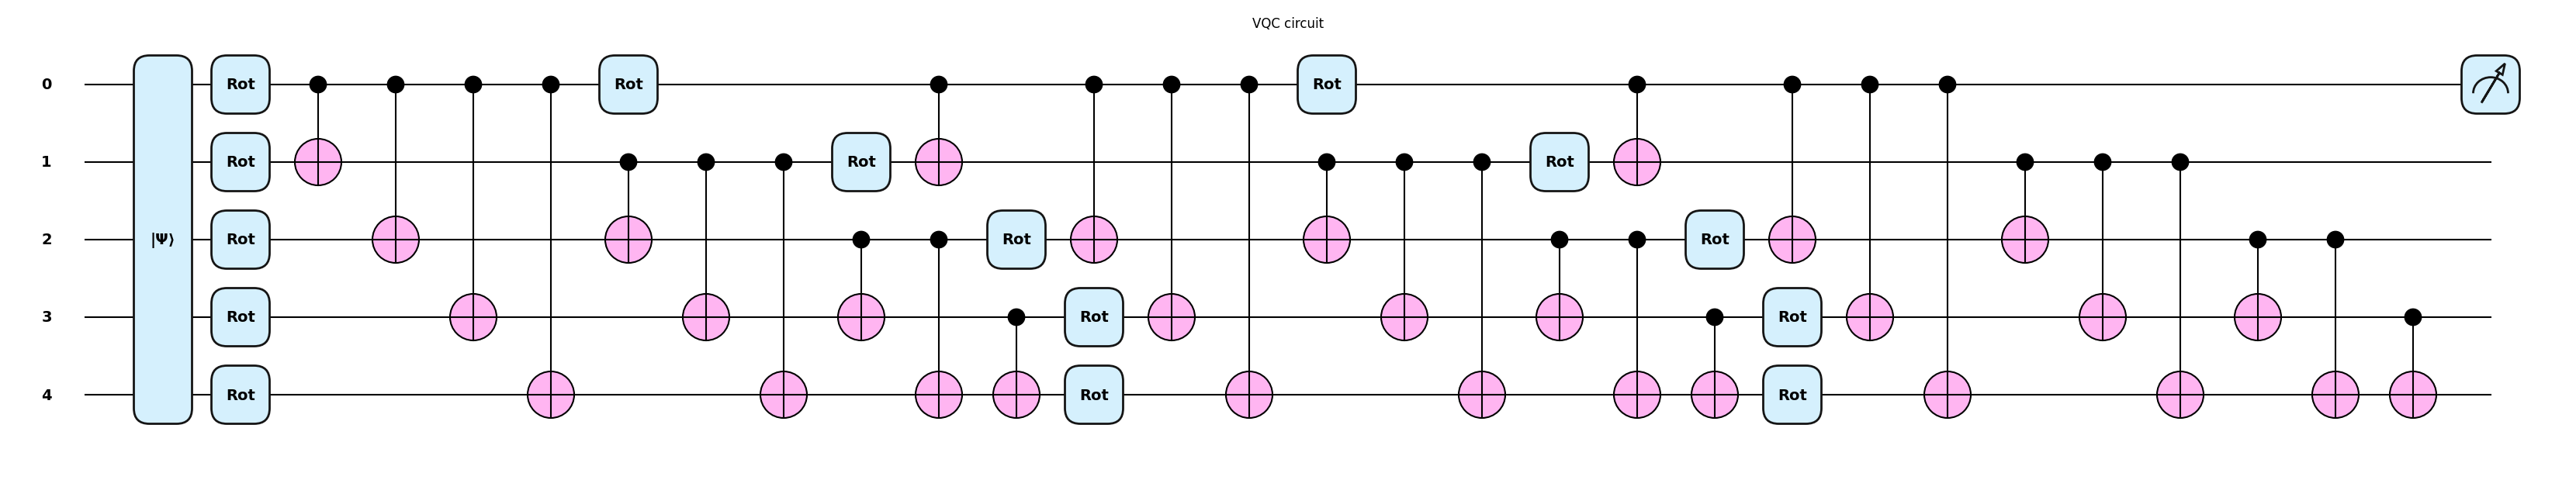

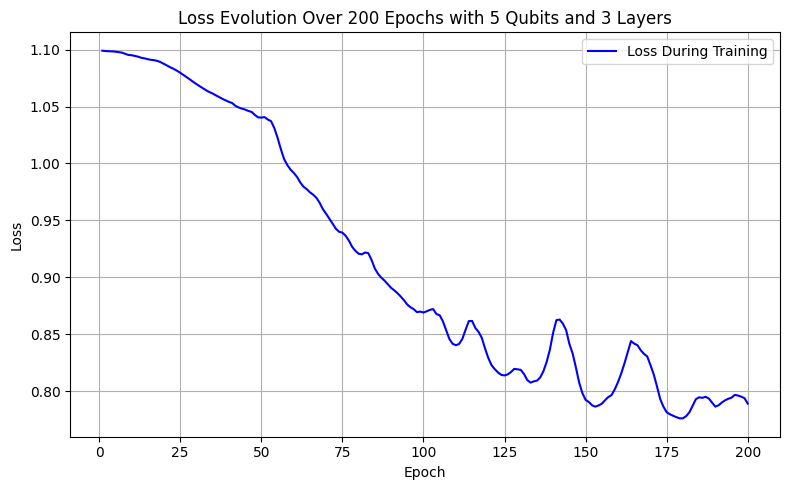

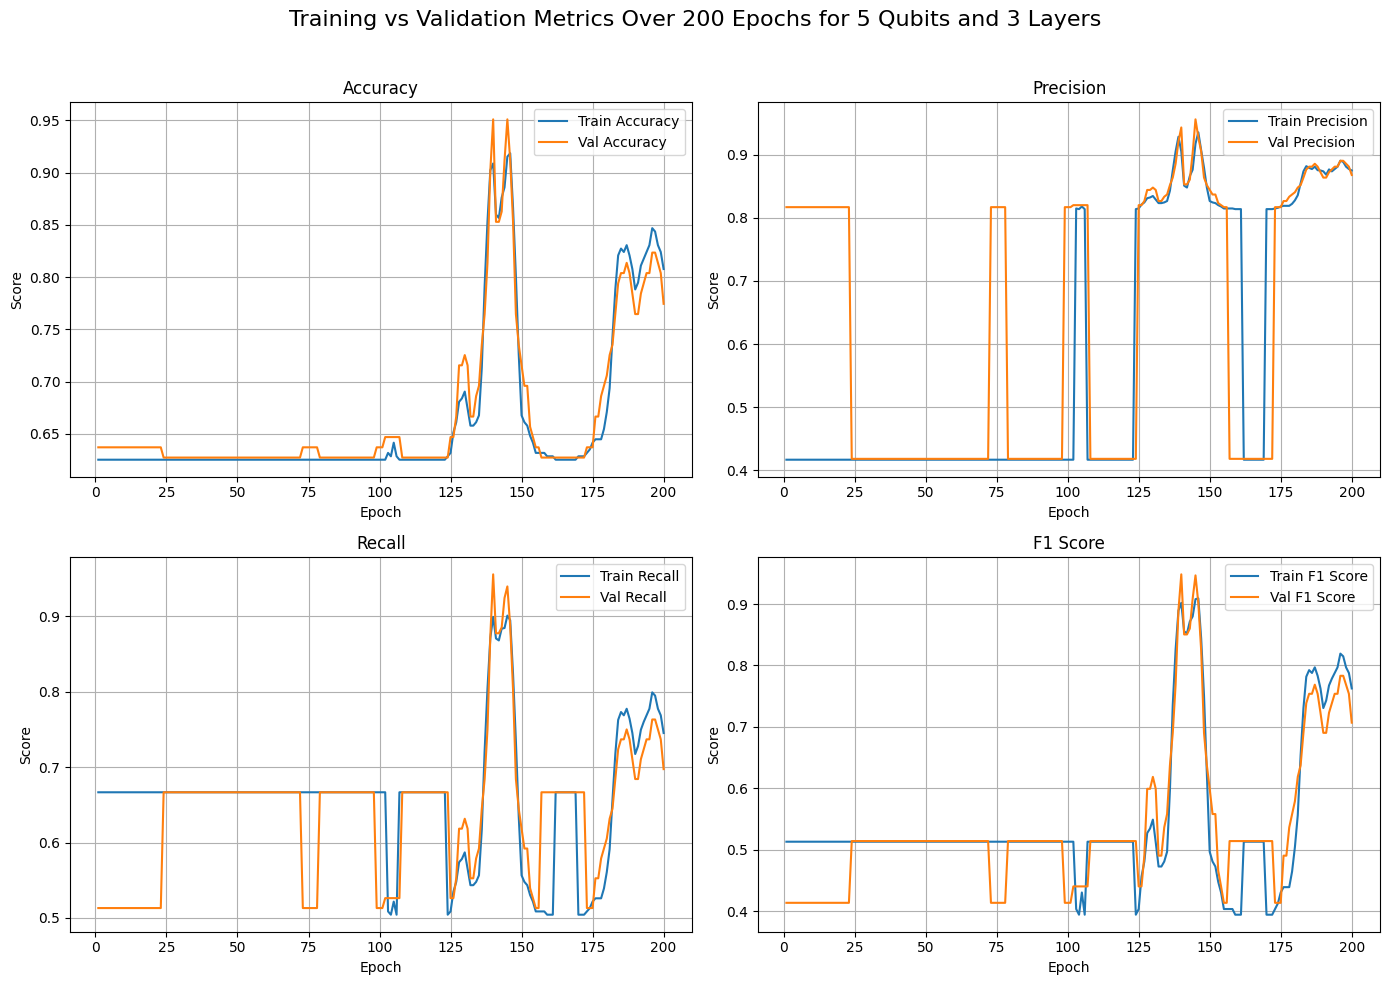

In [17]:
np.random.seed(0)
num_data = len(y_train)
num_train = int(0.75 * num_data)
index = np.random.permutation(range(num_data))

num_epochs = 200

layers=[x for x in range(1,11)]

num_qubits = n_qubits

best_layer=0
best_accuracy=0.0
best_weights=None
best_bias=0.0
best_losses=[]

best_train_acc=[]
best_train_prec=[]
best_train_rec=[]
best_train_f1=[]

best_val_acc=[]
best_val_prec=[]
best_val_rec=[]
best_val_f1=[]

test_acc=[]
test_prec=[]
test_rec=[]
test_f1=[]

best_epoch=0
biased=False


for num_layers in layers:

    weights_init = 0.01 * np.random.randn(num_layers, num_qubits, 3,requires_grad=True)
    bias_init = np.array(0.0,requires_grad=biased)

    opt = NesterovMomentumOptimizer(0.01)
    batch_size = 5
    # batch_size = 4


    # Tracking loss
    losses = []

    # Tracking Train accuracy
    tr_acc=[]

    # Tracking Validation accuracy
    val_acc=[]

    # Tracking Train precision
    tr_prec=[]

    # Tracking Validation precision
    val_prec=[]

    # Tracking Train recall
    tr_recall=[]

    # Tracking Validation recall
    val_recall=[]

    # Tracking Train F1
    tr_f1=[]

    # Tracking Validation F1
    val_f1=[]

    # Initialize weights
    weights = weights_init
    bias = bias_init
    
    val_best_acc=0.0
    val_best_weights=None
    val_best_bias=0.0

    val_best_epoch=0

    for it in range(num_epochs):
        # Mini-batch sampling
        # batch_index = np.random.randint(0, num_train, (batch_size,))
        batch_index = np.random.randint(0, num_data, (batch_size,))
        feats_train_batch = features[batch_index]
        Y_train_batch = y_train[batch_index]

        # Optimizer step
        # weights_new, bias_new, _, _ = opt.step(cost, weights, bias, feats_train_batch, Y_train_batch)
        weights, bias, _, _ = opt.step(cost, weights, bias, feats_train_batch, Y_train_batch)

        plot=False
        # Predictions
        pred_train = np.sign(variational_classifier(weights, bias, features,plot=plot))
        pred_val = np.sign(variational_classifier(weights, bias, features_val))

        # Metrics
        acc_train = accuracy_score(y_train, pred_train)
        acc_val = accuracy_score(y_val, pred_val)
        prec_train = precision_score(y_train,pred_train,zero_division=0,average='macro')
        prec_val = precision_score(y_val, pred_val, zero_division=0,average='macro')
        rec_train = recall_score(y_train,pred_train,zero_division=0,average='macro')
        rec_val = recall_score(y_val, pred_val, zero_division=0,average='macro')
        f1_train = f1_score(y_train,pred_train,zero_division=0,average='macro')
        f1_val = f1_score(y_val, pred_val, zero_division=0,average='macro')

        tr_acc.append(acc_train)
        val_acc.append(acc_val)
        tr_prec.append(prec_train)
        val_prec.append(prec_val)
        tr_recall.append(rec_train)
        val_recall.append(rec_val)
        tr_f1.append(f1_train)
        val_f1.append(f1_val)

        # Track loss
        _cost = cost(weights, bias, features, y_train)
        losses.append(_cost)

        if acc_val>val_best_acc:
            val_best_weights=weights.copy()
            val_best_bias=bias.copy()
            val_best_acc=acc_val
            val_best_epoch=it

    # After training: evaluate on test set
    weights=val_best_weights.copy()
    bias=val_best_bias
    pred_test = np.sign(variational_classifier(weights, bias, features_test))
    

    acc_test = accuracy_score(y_test, pred_test)
    prec_test = precision_score(y_test, pred_test, zero_division=0,average='macro')
    rec_test = recall_score(y_test, pred_test, zero_division=0,average='macro')
    f1_test = f1_score(y_test, pred_test, zero_division=0,average='macro')

    test_acc.append(acc_test)
    test_prec.append(prec_test)
    test_rec.append(rec_test)
    test_f1.append(f1_test)


    print(f"\n Test Set Evaluation achieved at epoch {val_best_epoch} (Number of layers {num_layers}):")
    print(f"Accuracy : {acc_test:.4f}")
    print(f"Precision: {prec_test:.4f}")
    print(f"Recall   : {rec_test:.4f}")
    print(f"F1-score : {f1_test:.4f}")

    if acc_test>best_accuracy:
        best_accuracy=acc_test
        best_layer=num_layers
        best_weights=weights.copy()
        best_bias=bias

        best_losses=losses
        best_epoch=val_best_epoch

        best_train_acc=tr_acc
        best_train_prec=tr_prec
        best_train_rec=tr_recall
        best_train_f1=tr_f1

        best_val_acc=val_acc
        best_val_prec=val_prec
        best_val_rec=val_recall
        best_val_f1=val_f1


# After training: evaluate on test set
pred_test = np.sign(variational_classifier(best_weights, best_bias, features_test,plot=True))

acc_test = accuracy_score(y_test, pred_test)
prec_test = precision_score(y_test, pred_test, zero_division=0,average='macro')
rec_test = recall_score(y_test, pred_test, zero_division=0,average='macro')
f1_test = f1_score(y_test, pred_test, zero_division=0,average='macro')


print(f"\n--> Test Set Evaluation achieved at best epoch {best_epoch} (Best Number of Layers is {best_layer}):")
print(f"Accuracy : {acc_test:.4f}")
print(f"Precision: {prec_test:.4f}")
print(f"Recall   : {rec_test:.4f}")
print(f"F1-score : {f1_test:.4f}")

# Plot loss over time
plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs + 1), best_losses,label='Loss During Training', linestyle='-', color='blue')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(f"Loss Evolution Over {num_epochs} Epochs with {num_qubits} Qubits and {best_layer} Layers")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

epochs_range = range(1, num_epochs + 1)

plt.figure(figsize=(14, 10))

# --- Accuracy ---
plt.subplot(2, 2, 1)
plt.plot(epochs_range, best_train_acc, label='Train Accuracy', linestyle='-')
plt.plot(epochs_range, best_val_acc, label='Val Accuracy', linestyle='-')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.legend()
plt.grid(True)

# --- Precision ---
plt.subplot(2, 2, 2)
plt.plot(epochs_range, best_train_prec, label='Train Precision', linestyle='-')
plt.plot(epochs_range, best_val_prec, label='Val Precision', linestyle='-')
plt.title('Precision')
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.legend()
plt.grid(True)

# --- Recall ---
plt.subplot(2, 2, 3)
plt.plot(epochs_range, best_train_rec, label='Train Recall', linestyle='-')
plt.plot(epochs_range, best_val_rec, label='Val Recall', linestyle='-')
plt.title('Recall')
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.legend()
plt.grid(True)

# --- F1 Score ---
plt.subplot(2, 2, 4)
plt.plot(epochs_range, best_train_f1, label='Train F1 Score', linestyle='-')
plt.plot(epochs_range, best_val_f1, label='Val F1 Score', linestyle='-')
plt.title('F1 Score')
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.legend()
plt.grid(True)

# --- Layout ---
plt.suptitle(f'Training vs Validation Metrics Over {num_epochs} Epochs for {num_qubits} Qubits and {best_layer} Layers', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [18]:
# print(f"Best Accuracy {best_accuracy:.4f} for {num_qubits} Qubits can be achieved with {best_layer} Layers")

# plt.figure(figsize=(8, 5))
# plt.plot(layers, test_acc,label='Test Accuracy', linestyle='-', color='blue')
# plt.plot(layers, test_prec,label='Test Precision', linestyle='-', color='orange')
# plt.plot(layers, test_rec,label='Test Recall', linestyle='-', color='green')
# plt.plot(layers, test_f1,label='Test F1', linestyle='-', color='red')
# plt.xlabel("Number of Layers")
# plt.ylabel("Score")
# plt.title(f"Test Metrics Over Number of Layers for {num_qubits} Qubits")
# plt.legend()
# plt.grid(True)
# plt.tight_layout()
# plt.show()


 Test Set Evaluation for BIASED Classifier achieved at epoch 0 (Number of layers 1):
Accuracy : 0.6408
Precision: 0.8186
Recall   : 0.5132
F1-score : 0.4149

 Test Set Evaluation for BIASED Classifier achieved at epoch 0 (Number of layers 2):
Accuracy : 0.6408
Precision: 0.8186
Recall   : 0.5132
F1-score : 0.4149

 Test Set Evaluation for BIASED Classifier achieved at epoch 144 (Number of layers 3):
Accuracy : 0.9223
Precision: 0.9210
Recall   : 0.9111
F1-score : 0.9156

 Test Set Evaluation for BIASED Classifier achieved at epoch 147 (Number of layers 4):
Accuracy : 0.9126
Precision: 0.9130
Recall   : 0.8980
F1-score : 0.9045

 Test Set Evaluation for BIASED Classifier achieved at epoch 143 (Number of layers 5):
Accuracy : 0.9223
Precision: 0.9210
Recall   : 0.9111
F1-score : 0.9156

 Test Set Evaluation for BIASED Classifier achieved at epoch 118 (Number of layers 6):
Accuracy : 0.9223
Precision: 0.9271
Recall   : 0.9057
F1-score : 0.9146

 Test Set Evaluation for BIASED Classifier 

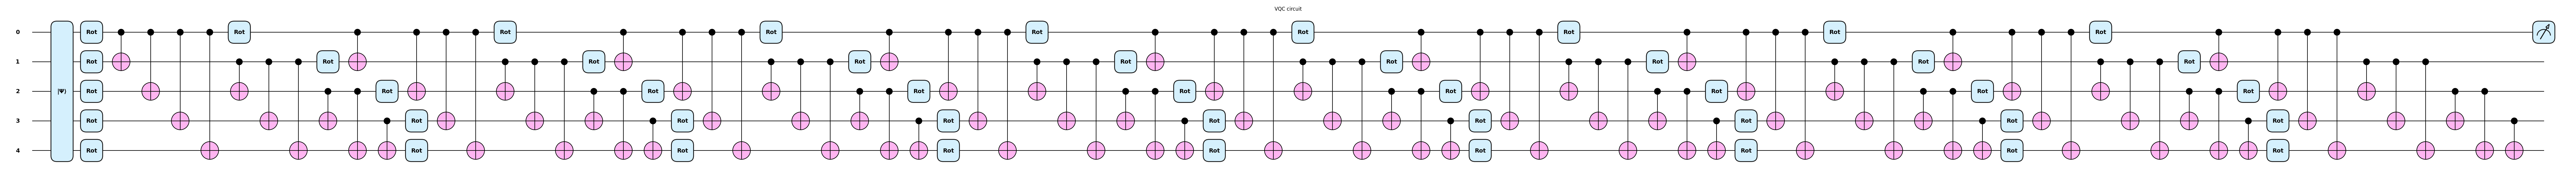

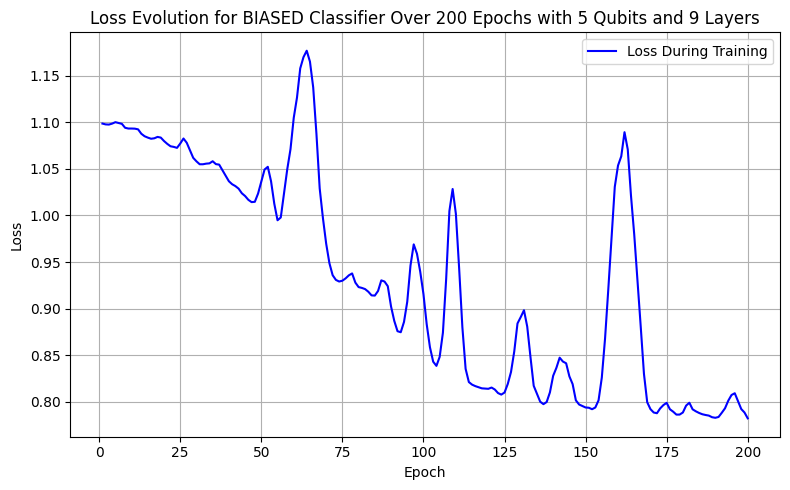

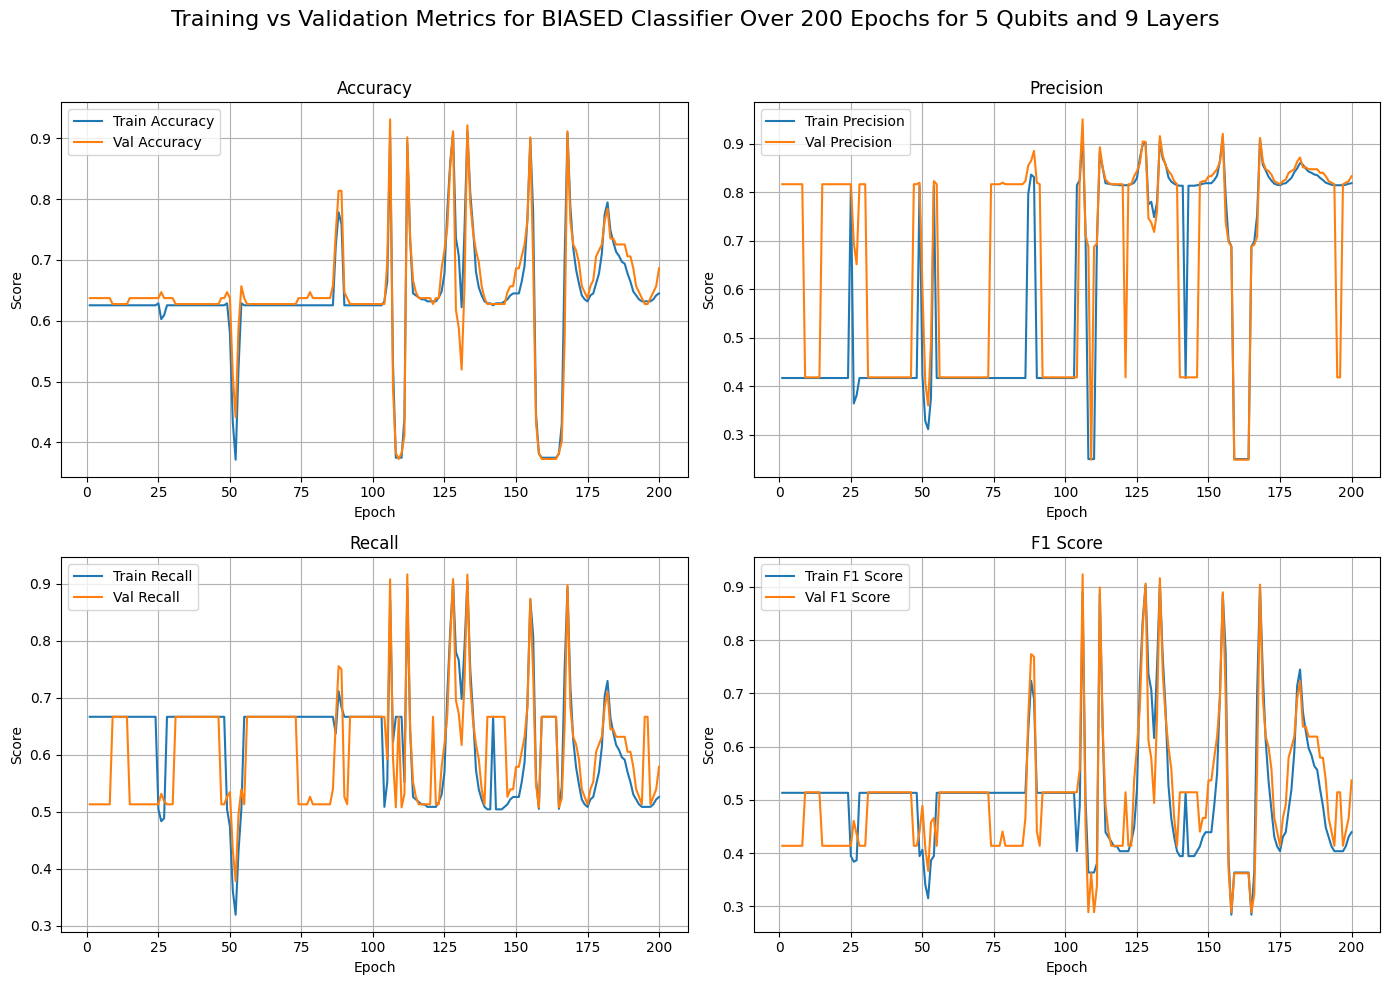

In [19]:
np.random.seed(0)
num_data = len(y_train)
num_train = int(0.75 * num_data)
index = np.random.permutation(range(num_data))

num_epochs = 200

layers=[x for x in range(1,11)]

num_qubits = n_qubits

best_layer=0
best_accuracy=0.0
best_weights=None
best_bias=0.0
best_losses=[]

best_train_acc=[]
best_train_prec=[]
best_train_rec=[]
best_train_f1=[]

best_val_acc=[]
best_val_prec=[]
best_val_rec=[]
best_val_f1=[]

biased_test_acc=[]
biased_test_prec=[]
biased_test_rec=[]
biased_test_f1=[]

best_epoch=0
biased=True

for num_layers in layers:

    weights_init = 0.01 * np.random.randn(num_layers, num_qubits, 3,requires_grad=True)
    bias_init = np.array(0.0,requires_grad=biased)

    opt = NesterovMomentumOptimizer(0.01)
    batch_size = 5
    # batch_size = 4


    # Tracking loss
    losses = []

    # Tracking Train accuracy
    tr_acc=[]

    # Tracking Validation accuracy
    val_acc=[]

    # Tracking Train precision
    tr_prec=[]

    # Tracking Validation precision
    val_prec=[]

    # Tracking Train recall
    tr_recall=[]

    # Tracking Validation recall
    val_recall=[]

    # Tracking Train F1
    tr_f1=[]

    # Tracking Validation F1
    val_f1=[]

    # Initialize weights
    weights = weights_init
    bias = bias_init
    
    val_best_acc=0.0
    val_best_weights=None
    val_best_bias=0.0

    val_best_epoch=0

    for it in range(num_epochs):
        # Mini-batch sampling
        # batch_index = np.random.randint(0, num_train, (batch_size,))
        batch_index = np.random.randint(0, num_data, (batch_size,))
        feats_train_batch = features[batch_index]
        Y_train_batch = y_train[batch_index]

        # Optimizer step
        # weights_new, bias_new, _, _ = opt.step(cost, weights, bias, feats_train_batch, Y_train_batch)
        weights, bias, _, _ = opt.step(cost, weights, bias, feats_train_batch, Y_train_batch)

        plot=False
        # Predictions
        pred_train = np.sign(variational_classifier(weights, bias, features,plot=plot))
        pred_val = np.sign(variational_classifier(weights, bias, features_val))

        # Metrics
        acc_train = accuracy_score(y_train, pred_train)
        acc_val = accuracy_score(y_val, pred_val)
        prec_train = precision_score(y_train,pred_train,zero_division=0,average='macro')
        prec_val = precision_score(y_val, pred_val, zero_division=0,average='macro')
        rec_train = recall_score(y_train,pred_train,zero_division=0,average='macro')
        rec_val = recall_score(y_val, pred_val, zero_division=0,average='macro')
        f1_train = f1_score(y_train,pred_train,zero_division=0,average='macro')
        f1_val = f1_score(y_val, pred_val, zero_division=0,average='macro')

        tr_acc.append(acc_train)
        val_acc.append(acc_val)
        tr_prec.append(prec_train)
        val_prec.append(prec_val)
        tr_recall.append(rec_train)
        val_recall.append(rec_val)
        tr_f1.append(f1_train)
        val_f1.append(f1_val)

        # Track loss
        _cost = cost(weights, bias, features, y_train)
        losses.append(_cost)

        if acc_val>val_best_acc:
            val_best_weights=weights.copy()
            val_best_bias=bias.copy()
            val_best_acc=acc_val
            val_best_epoch=it

    # After training: evaluate on test set
    weights=val_best_weights.copy()
    bias=val_best_bias
    pred_test = np.sign(variational_classifier(weights, bias, features_test))
    

    acc_test = accuracy_score(y_test, pred_test)
    prec_test = precision_score(y_test, pred_test, zero_division=0,average='macro')
    rec_test = recall_score(y_test, pred_test, zero_division=0,average='macro')
    f1_test = f1_score(y_test, pred_test, zero_division=0,average='macro')

    biased_test_acc.append(acc_test)
    biased_test_prec.append(prec_test)
    biased_test_rec.append(rec_test)
    biased_test_f1.append(f1_test)


    print(f"\n Test Set Evaluation for BIASED Classifier achieved at epoch {val_best_epoch} (Number of layers {num_layers}):")
    print(f"Accuracy : {acc_test:.4f}")
    print(f"Precision: {prec_test:.4f}")
    print(f"Recall   : {rec_test:.4f}")
    print(f"F1-score : {f1_test:.4f}")

    if acc_test>best_accuracy:
        best_accuracy=acc_test
        best_layer=num_layers
        best_weights=weights.copy()
        best_bias=bias.copy()

        best_losses=losses
        best_epoch=val_best_epoch

        best_train_acc=tr_acc
        best_train_prec=tr_prec
        best_train_rec=tr_recall
        best_train_f1=tr_f1

        best_val_acc=val_acc
        best_val_prec=val_prec
        best_val_rec=val_recall
        best_val_f1=val_f1


# After training: evaluate on test set
pred_test = np.sign(variational_classifier(best_weights, best_bias, features_test,plot=True))

acc_test = accuracy_score(y_test, pred_test)
prec_test = precision_score(y_test, pred_test, zero_division=0,average='macro')
rec_test = recall_score(y_test, pred_test, zero_division=0,average='macro')
f1_test = f1_score(y_test, pred_test, zero_division=0,average='macro')


print(f"\n--> Test Set Evaluation for BIASED achieved at best epoch {best_epoch} (Best Number of Layers is {best_layer}):")
print(f"Accuracy : {acc_test:.4f}")
print(f"Precision: {prec_test:.4f}")
print(f"Recall   : {rec_test:.4f}")
print(f"F1-score : {f1_test:.4f}")

# Plot loss over time
plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs + 1), best_losses,label='Loss During Training', linestyle='-', color='blue')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(f"Loss Evolution for BIASED Classifier Over {num_epochs} Epochs with {num_qubits} Qubits and {best_layer} Layers")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

epochs_range = range(1, num_epochs + 1)

plt.figure(figsize=(14, 10))

# --- Accuracy ---
plt.subplot(2, 2, 1)
plt.plot(epochs_range, best_train_acc, label='Train Accuracy', linestyle='-')
plt.plot(epochs_range, best_val_acc, label='Val Accuracy', linestyle='-')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.legend()
plt.grid(True)

# --- Precision ---
plt.subplot(2, 2, 2)
plt.plot(epochs_range, best_train_prec, label='Train Precision', linestyle='-')
plt.plot(epochs_range, best_val_prec, label='Val Precision', linestyle='-')
plt.title('Precision')
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.legend()
plt.grid(True)

# --- Recall ---
plt.subplot(2, 2, 3)
plt.plot(epochs_range, best_train_rec, label='Train Recall', linestyle='-')
plt.plot(epochs_range, best_val_rec, label='Val Recall', linestyle='-')
plt.title('Recall')
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.legend()
plt.grid(True)

# --- F1 Score ---
plt.subplot(2, 2, 4)
plt.plot(epochs_range, best_train_f1, label='Train F1 Score', linestyle='-')
plt.plot(epochs_range, best_val_f1, label='Val F1 Score', linestyle='-')
plt.title('F1 Score')
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.legend()
plt.grid(True)

# --- Layout ---
plt.suptitle(f'Training vs Validation Metrics for BIASED Classifier Over {num_epochs} Epochs for {num_qubits} Qubits and {best_layer} Layers', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [20]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming your lists are already populated:
# layers, biased_test_acc, test_acc, etc.

# Create a structured DataFrame
data = []
for i, layer in enumerate(layers):
    # Add Biased Data
    data.append({'Layers': layer, 'Score': biased_test_acc[i], 'Metric': 'Accuracy', 'Type': 'Biased'})
    data.append({'Layers': layer, 'Score': biased_test_prec[i], 'Metric': 'Precision', 'Type': 'Biased'})
    data.append({'Layers': layer, 'Score': biased_test_rec[i], 'Metric': 'Recall', 'Type': 'Biased'})
    data.append({'Layers': layer, 'Score': biased_test_f1[i], 'Metric': 'F1', 'Type': 'Biased'})
    
    # Add Unbiased Data
    data.append({'Layers': layer, 'Score': test_acc[i], 'Metric': 'Accuracy', 'Type': 'Unbiased'})
    data.append({'Layers': layer, 'Score': test_prec[i], 'Metric': 'Precision', 'Type': 'Unbiased'})
    data.append({'Layers': layer, 'Score': test_rec[i], 'Metric': 'Recall', 'Type': 'Unbiased'})
    data.append({'Layers': layer, 'Score': test_f1[i], 'Metric': 'F1', 'Type': 'Unbiased'})

df = pd.DataFrame(data)

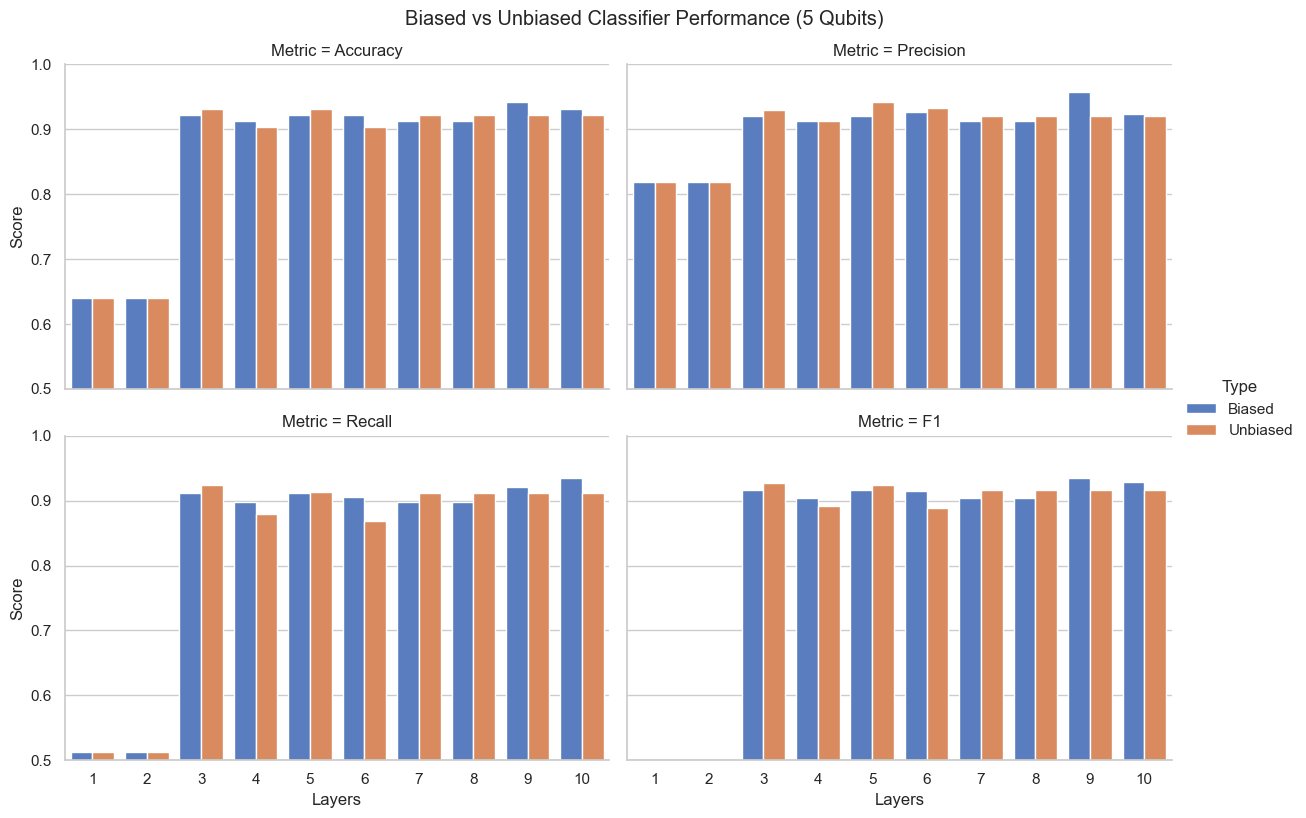

In [21]:
# Set a clean theme
sns.set_theme(style="whitegrid")

# Create the plot
g = sns.catplot(
    data=df, 
    x="Layers", 
    y="Score", 
    hue="Type", 
    col="Metric", 
    kind="bar", 
    col_wrap=2,   # 2 plots per row
    height=4, 
    aspect=1.5,
    palette="muted"
)

# Adjust the Y-axis to focus on the relevant range (optional)
# If you want to see the full 0-1 scale, remove the set_ylim line.
g.set(ylim=(0.5, 1.0)) 

# Add titles
g.figure.suptitle(f'Biased vs Unbiased Classifier Performance ({num_qubits} Qubits)', y=1.02)
plt.show()

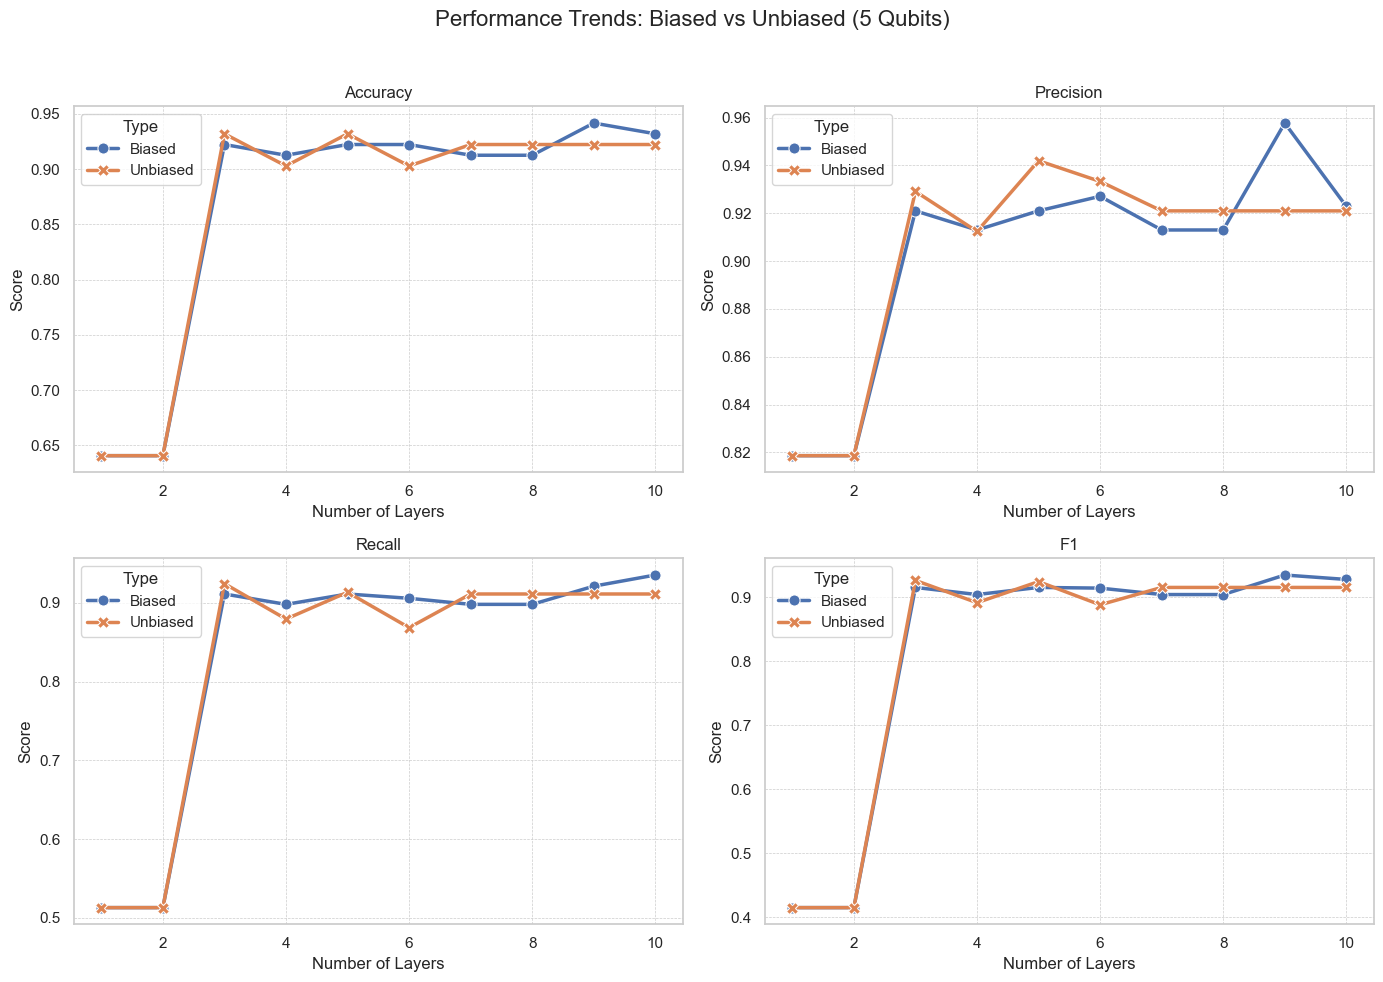

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1']

# Flatten axes for easy iteration
axes = axes.flatten()

for i, metric in enumerate(metrics):
    # Filter data for the specific metric
    subset = df[df['Metric'] == metric]
    
    sns.lineplot(
        data=subset, 
        x="Layers", 
        y="Score", 
        hue="Type", 
        style="Type", 
        markers=True,  # Adds dots at data points
        dashes=False, 
        ax=axes[i],
        linewidth=2.5,
        markersize=8
    )
    
    axes[i].set_title(metric)
    axes[i].set_xlabel("Number of Layers")
    axes[i].grid(True, which='both', linestyle='--', linewidth=0.5)

plt.suptitle(f'Performance Trends: Biased vs Unbiased ({num_qubits} Qubits)', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

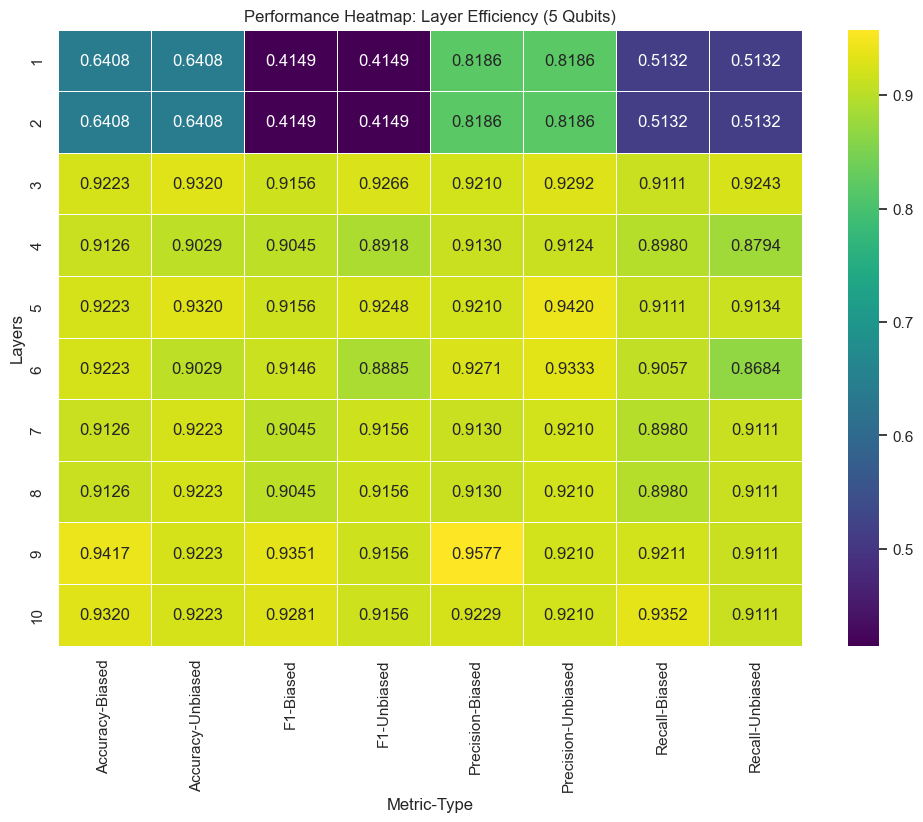

In [23]:
# Pivot data for heatmap: Rows = Layers, Cols = Metric + Type
heatmap_data = df.pivot_table(index="Layers", columns=["Metric", "Type"], values="Score")

plt.figure(figsize=(12, 8))
sns.heatmap(
    heatmap_data, 
    annot=True,      # Show the actual numbers
    fmt=".4f",       # 4 decimal places
    cmap="viridis",  # Color scheme
    linewidths=.5
)
plt.title(f"Performance Heatmap: Layer Efficiency ({num_qubits} Qubits)")
plt.show()

In [24]:
# opt = NesterovMomentumOptimizer(0.01)
# batch_size = 5
# # batch_size = 4
# num_epochs = 232

# # Tracking loss
# losses = []

# # Tracking Train accuracy
# tr_acc=[]

# # Tracking Validation accuracy
# val_acc=[]

# # Tracking Train precision
# tr_prec=[]

# # Tracking Validation precision
# val_prec=[]

# # Tracking Train recall
# tr_recall=[]

# # Tracking Validation recall
# val_recall=[]

# # Tracking Train F1
# tr_f1=[]

# # Tracking Validation F1
# val_f1=[]

# # Initialize weights
# weights = weights_init
# bias = bias_init

# for it in range(num_epochs):
#     # Mini-batch sampling
#     # batch_index = np.random.randint(0, num_train, (batch_size,))
#     batch_index = np.random.randint(0, num_data, (batch_size,))
#     feats_train_batch = features[batch_index]
#     Y_train_batch = y_train[batch_index]

#     # qml.StatePrep(feats_train_batch, wires=[0, 1],normalize=True,pad_with=0.1)
#     # print(feats_train_batch)
#     # Optimizer step
#     # weights_new, bias_new, _, _ = opt.step(cost, weights, bias, feats_train_batch, Y_train_batch)
#     weights, bias, _, _ = opt.step(cost, weights, bias, feats_train_batch, Y_train_batch)

#     plot=False
#     # Predictions
#     if it==num_epochs-1:
#         plot=True

#     pred_train = np.sign(variational_classifier(weights, bias, features,plot=plot))
#     pred_val = np.sign(variational_classifier(weights, bias, features_val))

#     # Metrics
#     acc_train = accuracy_score(y_train, pred_train)
#     acc_val = accuracy_score(y_val, pred_val)
#     prec_train = precision_score(y_train,pred_train,zero_division=0,average='macro')
#     prec_val = precision_score(y_val, pred_val, zero_division=0,average='macro')
#     rec_train = recall_score(y_train,pred_train,zero_division=0,average='macro')
#     rec_val = recall_score(y_val, pred_val, zero_division=0,average='macro')
#     f1_train = f1_score(y_train,pred_train,zero_division=0,average='macro')
#     f1_val = f1_score(y_val, pred_val, zero_division=0,average='macro')

#     tr_acc.append(acc_train)
#     val_acc.append(acc_val)
#     tr_prec.append(prec_train)
#     val_prec.append(prec_val)
#     tr_recall.append(rec_train)
#     val_recall.append(rec_val)
#     tr_f1.append(f1_train)
#     val_f1.append(f1_val)

#     # Track loss
#     _cost = cost(weights, bias, features, y_train)
#     losses.append(_cost)

#     if (it + 1) % 2 == 0:
#         print(
#             f"Iter: {it + 1:3d} | Cost: {_cost:0.7f} | "
#             f"Acc Train: {acc_train:0.4f} | Acc Val: {acc_val:0.4f} | "
#             f"Precision: {prec_val:0.4f} | Recall: {rec_val:0.4f} | F1: {f1_val:0.4f}"
#         )
#     # weights=weights_new
#     # bias-bias_new

# # After training: evaluate on test set
# pred_test = np.sign(variational_classifier(weights, bias, features_test))

# acc_test = accuracy_score(y_test, pred_test)
# prec_test = precision_score(y_test, pred_test, zero_division=0,average='macro')
# rec_test = recall_score(y_test, pred_test, zero_division=0,average='macro')
# f1_test = f1_score(y_test, pred_test, zero_division=0,average='macro')

# print("\n Final Test Set Evaluation:")
# print(f"Accuracy : {acc_test:.4f}")
# print(f"Precision: {prec_test:.4f}")
# print(f"Recall   : {rec_test:.4f}")
# print(f"F1-score : {f1_test:.4f}")

# # Plot loss over time
# plt.figure(figsize=(8, 5))
# plt.plot(range(1, num_epochs + 1), losses, linestyle='-', color='blue')
# plt.xlabel("Epoch")
# plt.ylabel("Loss")
# plt.title("Loss Evolution Over Epochs")
# plt.grid(True)
# plt.tight_layout()
# plt.show()

# epochs_range = range(1, num_epochs + 1)

# plt.figure(figsize=(14, 10))

# # --- Accuracy ---
# plt.subplot(2, 2, 1)
# plt.plot(epochs_range, tr_acc, label='Train Accuracy', linestyle='-')
# plt.plot(epochs_range, val_acc, label='Val Accuracy', linestyle='-')
# plt.title('Accuracy')
# plt.xlabel('Epoch')
# plt.ylabel('Score')
# plt.legend()
# plt.grid(True)

# # --- Precision ---
# plt.subplot(2, 2, 2)
# plt.plot(epochs_range, tr_prec, label='Train Precision', linestyle='-')
# plt.plot(epochs_range, val_prec, label='Val Precision', linestyle='-')
# plt.title('Precision')
# plt.xlabel('Epoch')
# plt.ylabel('Score')
# plt.legend()
# plt.grid(True)

# # --- Recall ---
# plt.subplot(2, 2, 3)
# plt.plot(epochs_range, tr_recall, label='Train Recall', linestyle='-')
# plt.plot(epochs_range, val_recall, label='Val Recall', linestyle='-')
# plt.title('Recall')
# plt.xlabel('Epoch')
# plt.ylabel('Score')
# plt.legend()
# plt.grid(True)

# # --- F1 Score ---
# plt.subplot(2, 2, 4)
# plt.plot(epochs_range, tr_f1, label='Train F1 Score', linestyle='-')
# plt.plot(epochs_range, val_f1, label='Val F1 Score', linestyle='-')
# plt.title('F1 Score')
# plt.xlabel('Epoch')
# plt.ylabel('Score')
# plt.legend()
# plt.grid(True)

# # --- Layout ---
# plt.suptitle('Training vs Validation Metrics Over Epochs', fontsize=16)
# plt.tight_layout(rect=[0, 0, 1, 0.96])
# plt.show()

In [25]:
def print_metrics(metrics_dict, name):
    print(f"\n{name} Set:")
    print(f"  Accuracy : {metrics_dict['accuracy']:.4f}")
    print(f"  Precision: {metrics_dict['precision']:.4f}")
    print(f"  Recall   : {metrics_dict['recall']:.4f}")
    print(f"  F1-Score : {metrics_dict['f1']:.4f}")

def get_metrics(x,y,clf):
    metrics_dict={}
    metrics_dict['accuracy'] = np.mean(cross_val_score(clf,x,y,scoring='accuracy',cv=5))
    metrics_dict['precision'] =np.mean(cross_val_score(clf,x,y,scoring='precision',cv=5))
    metrics_dict['recall'] =np.mean(cross_val_score(clf,x,y,scoring='recall',cv=5))
    metrics_dict['f1'] =np.mean(cross_val_score(clf,x,y,scoring='f1',cv=5))

    return metrics_dict

In [26]:
# Classical ML method: SVM

svm_clf = SVC(kernel='linear', C=1.0, random_state=42)
svm_clf.fit(x_train, y_train)

train_dict=get_metrics(x_train,y_train,clf=svm_clf)
val_dict=get_metrics(x_val,y_val,clf=svm_clf)
test_dict=get_metrics(x_clean_test,y_test,clf=svm_clf)

print("-----> SVM Results <-----")
print_metrics(train_dict, "Train")
print_metrics(val_dict, "Validation")
print_metrics(test_dict, "Test")

-----> SVM Results <-----

Train Set:
  Accuracy : 0.9544
  Precision: 0.9587
  Recall   : 0.9217
  F1-Score : 0.9380

Validation Set:
  Accuracy : 0.9414
  Precision: 0.9200
  Recall   : 0.9464
  F1-Score : 0.9268

Test Set:
  Accuracy : 0.9319
  Precision: 0.9242
  Recall   : 0.8964
  F1-Score : 0.9002


In [27]:
# Classical ML method: Logistic Regression
lr_clf = LogisticRegression(random_state=42)
lr_clf.fit(x_train, y_train)

train_dict=get_metrics(x_train,y_train,clf=lr_clf)
val_dict=get_metrics(x_val,y_val,clf=lr_clf)
test_dict=get_metrics(x_clean_test,y_test,clf=lr_clf)

print("-----> Logistic Regression Results <-----")
print_metrics(train_dict, "Train")
print_metrics(val_dict, "Validation")
print_metrics(test_dict, "Test")

-----> Logistic Regression Results <-----

Train Set:
  Accuracy : 0.9414
  Precision: 0.9418
  Recall   : 0.9043
  F1-Score : 0.9201

Validation Set:
  Accuracy : 0.9514
  Precision: 0.9600
  Recall   : 0.9250
  F1-Score : 0.9359

Test Set:
  Accuracy : 0.9033
  Precision: 0.8956
  Recall   : 0.8464
  F1-Score : 0.8602


In [28]:
# Classical ML method: Random Forest
forest_clf = RandomForestClassifier(random_state=42)
forest_clf.fit(x_train, y_train)

train_dict=get_metrics(x_train,y_train,clf=forest_clf)
val_dict=get_metrics(x_val,y_val,clf=forest_clf)
test_dict=get_metrics(x_clean_test,y_test,clf=forest_clf)

print("-----> Random Forest Results <-----")
print_metrics(train_dict, "Train")
print_metrics(val_dict, "Validation")
print_metrics(test_dict, "Test")

-----> Random Forest Results <-----

Train Set:
  Accuracy : 0.9448
  Precision: 0.9365
  Recall   : 0.9217
  F1-Score : 0.9262

Validation Set:
  Accuracy : 0.9514
  Precision: 0.9556
  Recall   : 0.9214
  F1-Score : 0.9325

Test Set:
  Accuracy : 0.9614
  Precision: 0.9750
  Recall   : 0.9250
  F1-Score : 0.9467
